In [1]:
!pip install pandas scikit-learn joblib

In [2]:
!wget -q "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip" -O sms_spam_collection.zip
!unzip -o sms_spam_collection.zip -d data
!find data -type f

Archive:  sms_spam_collection.zip
  inflating: data/SMSSpamCollection  
  inflating: data/readme             
data/readme
data/SMSSpamCollection


In [3]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Load the tab-separated dataset
data = pd.read_csv(
    "data/SMSSpamCollection",
    sep="\t",
    names=["label", "text"],
    header=None
)

# Convert labels: ham = 0 and spam = 1
data["label_number"] = data["label"].map({"ham": 0, "spam": 1})

# Split messages and labels into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    data["text"],
    data["label_number"],
    test_size=0.2,
    random_state=42,
    stratify=data["label_number"]
)

# Convert text to numbers, then train the classifier
model = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

# Test the trained model
predictions = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print("\nClassification report:\n")
print(classification_report(y_test, predictions, target_names=["Ham", "Spam"]))

# Save the trained model
joblib.dump(model, "spam_model.pkl")
print("\nModel saved as spam_model.pkl")

Accuracy: 97.04%

Classification report:

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Model saved as spam_model.pkl


In [4]:
def check_message(message):
    prediction = model.predict([message])[0]
    spam_probability = model.predict_proba([message])[0][1]

    if prediction == 1:
        print(f"Result: SPAM 🚨")
    else:
        print(f"Result: NOT SPAM ✅")

    print(f"Spam probability: {spam_probability:.2%}")


check_message("Congratulations! You won a free iPhone. Click here to claim it now.")

Result: SPAM 🚨
Spam probability: 72.07%


In [5]:
check_message("Hi, are we still meeting at the library at 5 PM?")

Result: NOT SPAM ✅
Spam probability: 1.88%


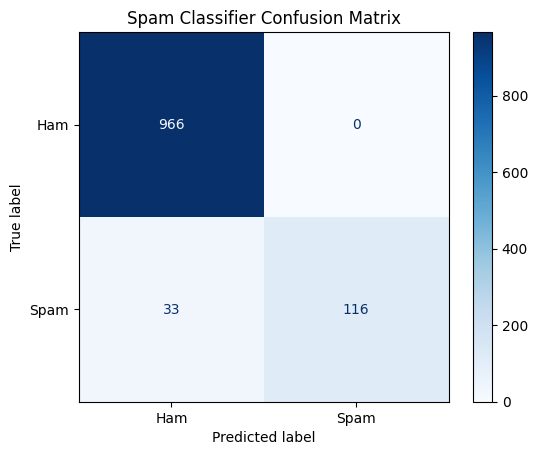

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Ham", "Spam"],
    cmap="Blues"
)

plt.title("Spam Classifier Confusion Matrix")
plt.show()

In [7]:
results = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": predictions
})

missed_spam = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print(f"Missed spam messages: {len(missed_spam)}")
display(missed_spam[["message"]].head(10))

Missed spam messages: 33


,message
5,FreeMsg Hey there darling it's been 3 week's n...
3750,Dear Voucher Holder 2 claim your 1st class air...
856,Talk sexy!! Make new friends or fall in love i...
3141,sexy sexy cum and text me im wet and warm and ...
1663,Hi if ur lookin 4 saucy daytime fun wiv busty ...
3981,ringtoneking 84484
3360,Sorry I missed your call let's talk when you h...
3548,Rock yr chik. Get 100's of filthy films &XXX p...
5449,"Latest News! Police station toilet stolen, cop..."
5098,TheMob>Hit the link to get a premium Pink Pant...


In [8]:
!pip -q install gradio

In [9]:
import gradio as gr

def predict_spam(message):
    prediction = model.predict([message])[0]
    spam_probability = model.predict_proba([message])[0][1]

    if prediction == 1:
        result = "🚨 SPAM"
    else:
        result = "✅ NOT SPAM"

    return f"{result}\nSpam probability: {spam_probability:.2%}"


app = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type or paste a message here..."
    ),
    outputs="text",
    title="SMS Spam Classifier",
    description="A beginner machine-learning project using TF-IDF and Naive Bayes."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60da4f145902cc1dd6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
from google.colab import files

files.download("spam_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>